# Retrieving SatNOGS on LASARsat

NORAD ID - 62391

In [7]:
import pandas as pd

csv_df = pd.read_csv("lasarsat_observations.csv")
print(csv_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          25 non-null     int64  
 1   start                       25 non-null     str    
 2   end                         25 non-null     str    
 3   ground_station              25 non-null     int64  
 4   transmitter                 25 non-null     str    
 5   norad_cat_id                25 non-null     int64  
 6   payload                     25 non-null     str    
 7   waterfall                   25 non-null     str    
 8   demoddata                   25 non-null     str    
 9   station_name                25 non-null     str    
 10  station_lat                 25 non-null     float64
 11  station_lng                 25 non-null     float64
 12  station_alt                 25 non-null     int64  
 13  archived                    25 non-null     bool

## Pulling Data

Run the python other python script: `get_lasarsat.py`

In [8]:
cols = ["id", "start", "end", "norad_cat_id", "ground_station", "observation_frequency", "waterfall", 'station_lat', 
    'station_lng', 'station_alt', 'tle1', 'tle2', 'tle_source',
    'transmitter_downlink_low']
obs_df = csv_df[cols].copy()

obs_df["start"] = pd.to_datetime(obs_df["start"])
obs_df["end"] = pd.to_datetime(obs_df["end"])
obs_df["duration_s"] = (obs_df["end"] - obs_df["start"]).dt.total_seconds()

obs_df["tle_complete"] = csv_df["tle1"] + "\n" + csv_df["tle2"] # only needed to see how much unique TLEs there are

print(obs_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   id                        25 non-null     int64              
 1   start                     25 non-null     datetime64[us, UTC]
 2   end                       25 non-null     datetime64[us, UTC]
 3   norad_cat_id              25 non-null     int64              
 4   ground_station            25 non-null     int64              
 5   observation_frequency     25 non-null     int64              
 6   waterfall                 25 non-null     str                
 7   station_lat               25 non-null     float64            
 8   station_lng               25 non-null     float64            
 9   station_alt               25 non-null     int64              
 10  tle1                      25 non-null     str                
 11  tle2                      25 non

In [9]:
diff = obs_df["observation_frequency"] - obs_df["transmitter_downlink_low"]
print(diff.describe())
print(diff.value_counts().head())

count    25.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64
0    25
Name: count, dtype: int64


## Time Frame and TLE split of data

In [10]:
print("Data spans:", obs_df["start"].min(), "to", obs_df["end"].max())
print("Duration:", obs_df["end"].max() - obs_df["start"].min())

print("\n\nUnique TLEs:", obs_df["tle_complete"].nunique())

groups = obs_df.groupby("tle_complete").groups

for tle, idx in groups.items():
    print(f"\n{len(idx)} observation(s):")
    print(tle)
    print("Index:", list(idx))

Data spans: 2026-09-30 04:35:09+00:00 to 2026-09-30 20:01:56+00:00
Duration: 0 days 15:26:47


Unique TLEs: 2

24 observation(s):
1 62391U 24247Q   26272.34328264  .00032546  00000-0  51014-3 0  9995
2 62391  44.9734  34.0435 0010308 286.8305  73.1457 15.53126498 99477
Index: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

1 observation(s):
1 62391U 24247Q   26273.30802020  .00027995  00000-0  43909-3 0  9995
2 62391  44.9730  28.5665 0010095 292.5073  67.4751 15.53182724 99629
Index: [0]


---
# FUNCTIONS

### Predict Doppler from TLE

In [11]:
import numpy as np
from skyfield.api import load, wgs84, EarthSatellite

ts = load.timescale()
C = 299792458.0

def pred_fD(row, step_s=10):
    # Predict Doppler shift of observation from prior TLE
    # Inputs:
    #   row: filtered observation from SatNOGS (pandas.Series)
    #   step_s: spacing between predicted Doppler points (lineup with waterfall)
    # Outputs:
    #   New DataFrame (or single row as pandas.Series) with time,
    #       f_rx_hz and doppler_hz

    # Initialise satelitte and groundstation from TLE and geodetic coords
    sat = EarthSatellite(row["tle1"], row["tle2"], ts=ts)
    station = wgs84.latlon(row["station_lat"], row["station_lng"], 
                            elevation_m=row["station_alt"])
    
    # Make sure UTC time zone
    t0 = pd.Timestamp(row["start"]).tz_convert("UTC")
    t1 = pd.Timestamp(row["end"]).tz_convert("UTC")
    times = pd.date_range(t0, t1, freq=f"{step_s}s")
    t = ts.from_datetimes(times.to_pydatetime())

    X_rel = (sat - station).at(t)
    rho_mag = X_rel.distance().m

    # Range rate by finite distance, at 1s
    t_b = ts.from_datetimes((times + pd.Timedelta(seconds=1)).to_pydatetime())
    rho_mag_b = (sat - station).at(t_b).distance().m 
    rho_dot = rho_mag_b - rho_mag

    f_tx = row["transmitter_downlink_low"]  # Transmitted Frequency
    f_rx = f_tx * (1 - rho_dot / C)         # Received Frequency
    f_D = f_rx - f_tx                       # Doppler whoshift

    return pd.DataFrame({"time": times, "f_rx_hz": f_rx, "doppler_hz": f_D})


---

## Analysing a single observation

### Predicted Doppler shift from TLE

In [12]:
pass_1 = obs_df.iloc[0].copy(deep=True)

pred_fD_1 = pred_fD(pass_1)
print(pred_fD_1.info())

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   time        27 non-null     datetime64[us, UTC]
 1   f_rx_hz     27 non-null     float64            
 2   doppler_hz  27 non-null     float64            
dtypes: datetime64[us, UTC](1), float64(2)
memory usage: 780.0 bytes
None


### Measured Doppler shift from Waterfall

In [16]:
import urllib.request
from PIL import Image

url = pass_1["waterfall"]
urllib.request.urlretrieve(url, "pass-1-waterfall.png")

('pass-1-waterfall.png', <http.client.HTTPMessage at 0x7fab0c731940>)

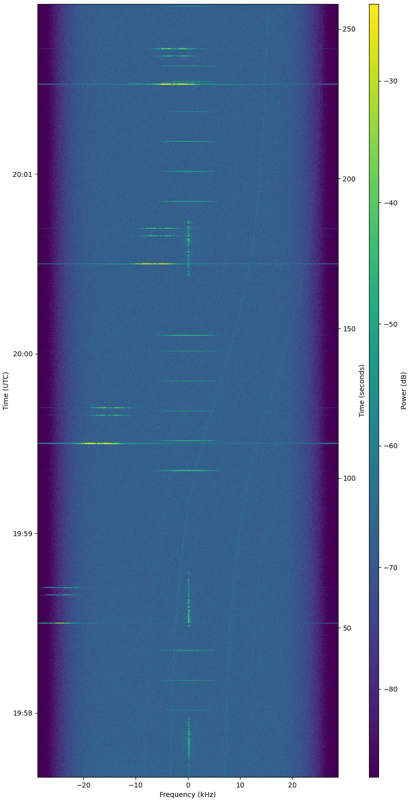

In [19]:
waterfall_1 = Image.open(r"pass-1-waterfall.png")
w, h = waterfall_1.size
display(waterfall_1.resize((w // 2, h // 2)))

### Comparing Predicted vs Measured Doppler shift